# Notebook 2. EDA, leave-one-out split и базовые модели

В этом ноутбуке используется финальный сабсэмпл, сформированный на предыдущем этапе. Здесь уже не меняется состав данных: задача состоит в том, чтобы описать полученную выборку, построить единую схему train / validation / test и оценить несколько базовых рекомендательных моделей.

Основные шаги ноутбука:

1. провести компактный EDA финального сабсэмпла
2. проверить распределения активности пользователей, популярности треков, organic / non-organic interactions и played ratio
3. построить leave-one-out split
4. обучить и оценить базовые модели: Most Popular, Last Item, Item-to-Item и GRU
5. сравнить модели по единому набору метрик.

Leave-one-out используется для постановки next-item prediction: для каждого пользователя последнее событие берётся как test target, предпоследнее - как validation target, а вся предыдущая история используется для обучения.


## 1. Импорты и загрузка финального сабсэмпла

In [1]:
!pip install -q tqdm pyarrow

In [2]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = 120
pd.options.display.max_rows = 120
sns.set_theme(style="whitegrid")

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [3]:
from google.colab import drive

drive.mount("/content/drive")
DATA_DIR = "/content/drive/MyDrive/Курсовая/final_subsample"

# загружаю финальный сабсэмпл из предыдущего ноутбука
final_events = pd.read_parquet(f"{DATA_DIR}/final_events.parquet")

# привожу timestamp к числовому формату и убираю строки без времени
final_events["timestamp"] = pd.to_numeric(final_events["timestamp"], errors="coerce")
final_events = final_events.dropna(subset=["timestamp"])
final_events["timestamp"] = final_events["timestamp"].astype("int64")

final_events["is_organic"] = final_events["is_organic"].astype(int)
final_events["played_ratio_pct"] = pd.to_numeric(final_events["played_ratio_pct"], errors="coerce")
final_events = (final_events.drop_duplicates(subset=["uid", "item_id", "timestamp"]).sort_values(["uid", "timestamp"]).reset_index(drop=True))

print(final_events.shape)
final_events.head()

Mounted at /content/drive
(10206636, 5)


,uid,item_id,timestamp,is_organic,played_ratio_pct
0,100,1441281,39420,0,100.0
1,100,3397170,40360,0,46.0
2,100,1449307,40640,0,100.0
3,100,2996197,40885,0,100.0
4,100,6474571,41130,0,100.0


## 2. Compact EDA

Сначала проверяю базовые характеристики финального сабсэмпла: число событий, пользователей и треков, среднюю длину пользовательской истории, популярность треков, долю organic / non-organic interactions и played ratio.

In [4]:
user_len = final_events.groupby("uid").size()
item_pop = final_events.groupby("item_id").size()

eda_summary = pd.DataFrame({
    "metric": [
        "events",
        "users",
        "tracks",
        "mean events per user",
        "median events per user",
        "mean listens per track",
        "median listens per track",
        "organic share",
        "non-organic share",
        "mean played ratio",
        "median played ratio"
    ],
    "value": [
        len(final_events),
        final_events["uid"].nunique(),
        final_events["item_id"].nunique(),
        round(user_len.mean(), 2),
        round(user_len.median(), 2),
        round(item_pop.mean(), 2),
        round(item_pop.median(), 2),
        round(final_events["is_organic"].mean(), 4),
        round(1 - final_events["is_organic"].mean(), 4),
        round(final_events["played_ratio_pct"].mean(), 4),
        round(final_events["played_ratio_pct"].median(), 4)]})

eda_summary

,metric,value
0,events,1.020664e+07
1,users,4.998000e+03
2,tracks,3.000000e+05
3,mean events per user,2.042140e+03
4,median events per user,1.281000e+03
5,mean listens per track,3.402000e+01
6,median listens per track,2.000000e+00
7,organic share,5.094000e-01
8,non-organic share,4.906000e-01
9,mean played ratio,6.487940e+01


**Вывод:** Финальный сабсэмпл содержит около 10.2 млн событий, 4998 пользователей и 300 000 треков. Средняя длина пользовательской истории составляет примерно 2042 события, медианная это 1281 событие. Это достаточно длинные последовательности, поэтому данные подходят для sequential recommendation.

Доля organic interactions составляет около 0.51, non-organic примерно около 0.49, то есть баланс между двумя типами взаимодействий сохраняется. Средний played ratio находится около 64.9, а медиана равна 100, что говорит о большом числе полных прослушиваний при наличии заметной доли неполных.

Далее визуально смотрю на распределения пользовательской активности и популярности треков. Оба распределения показаны в логарифмированном виде, потому что в рекомендательных данных обычно есть сильная неравномерность: часть пользователей очень активна, а часть треков встречается намного чаще остальных.

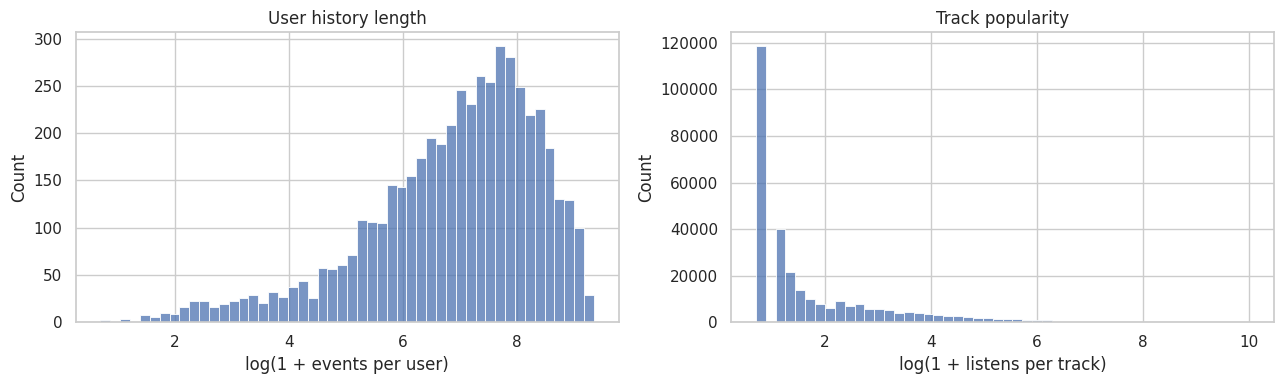

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(np.log1p(user_len), bins=50, ax=axes[0])
axes[0].set_title("User history length")
axes[0].set_xlabel("log(1 + events per user)")

sns.histplot(np.log1p(item_pop), bins=50, ax=axes[1])
axes[1].set_title("Track popularity")
axes[1].set_xlabel("log(1 + listens per track)")

plt.tight_layout()
plt.show()

**Вывод:**  Пользовательские истории достаточно длинные, поэтому данные подходят для sequential recommendation. При этом популярность треков распределена неравномерно: небольшая часть треков получает основную долю прослушиваний.

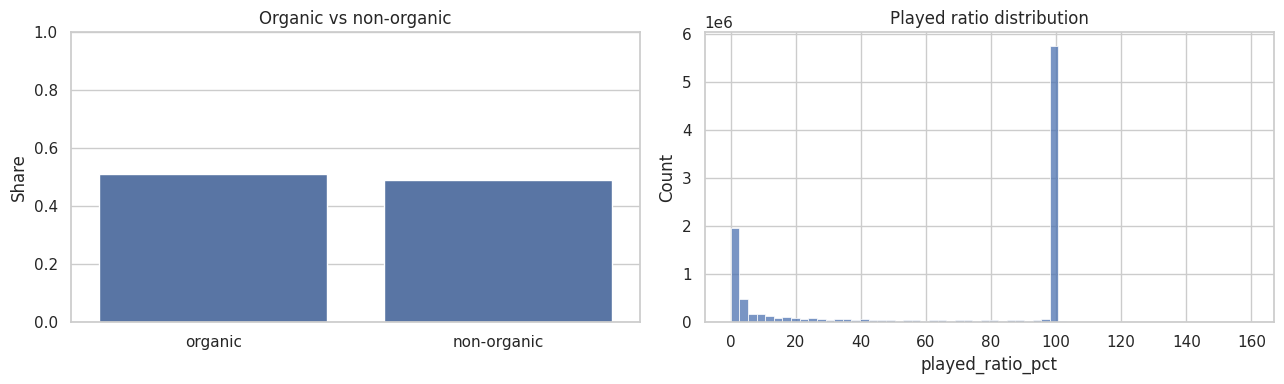

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

organic_plot = (
    final_events["is_organic"]
    .value_counts(normalize=True)
    .rename_axis("is_organic")
    .reset_index(name="share")
)
organic_plot["label"] = organic_plot["is_organic"].map({1: "organic", 0: "non-organic"})

sns.barplot(data=organic_plot, x="label", y="share", ax=axes[0])
axes[0].set_title("Organic vs non-organic")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share")
axes[0].set_ylim(0, 1)

sns.histplot(final_events["played_ratio_pct"].dropna(), bins=60, ax=axes[1])
axes[1].set_title("Played ratio distribution")
axes[1].set_xlabel("played_ratio_pct")

plt.tight_layout()
plt.show()

**Вывод:** Organic и non-organic interactions представлены почти в равных долях. Распределение played_ratio_pct показывает пик около 100, то есть многие прослушивания являются полными.

In [7]:
item_pop_df = item_pop.reset_index()
item_pop_df.columns = ["item_id", "n_listens"]
item_pop_df["log_n_listens"] = np.log1p(item_pop_df["n_listens"])
item_pop_df["popularity_bin"] = pd.qcut(item_pop_df["log_n_listens"].rank(method="first"), q=10, labels=False, duplicates="drop").astype(int)
events_with_bins = final_events.merge(item_pop_df[["item_id", "popularity_bin"]], on="item_id", how="left")

In [8]:
pop_bin_summary = (events_with_bins.groupby("popularity_bin").agg(tracks=("item_id", "nunique"), events=("item_id", "size"), organic_share=("is_organic", "mean"), mean_played_ratio=("played_ratio_pct", "mean"))
    .reset_index())

pop_bin_summary

,popularity_bin,tracks,events,organic_share,mean_played_ratio
0,0,30000,30000,0.724167,44.965833
1,1,30000,30000,0.717633,44.804333
2,2,30000,30000,0.722167,45.259767
3,3,30000,31403,0.715155,45.412285
4,4,30000,60000,0.627517,53.532100
5,5,30000,81362,0.597490,56.960485
6,6,30000,140873,0.549325,60.763943
7,7,30000,276824,0.543504,63.018842
8,8,30000,733777,0.544390,64.557186
9,9,30000,8792397,0.500279,65.454403


**Вывод:** Хотя по числу треков popularity bins сбалансированы, события распределены неравномерно: большая часть прослушиваний приходится на самые популярные треки.

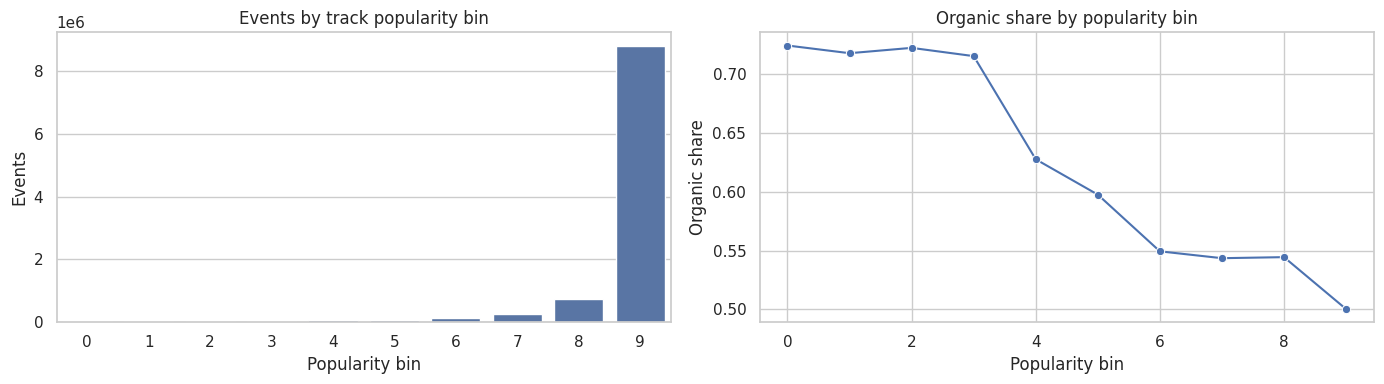

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=pop_bin_summary, x="popularity_bin", y="events", ax=axes[0])
axes[0].set_title("Events by track popularity bin")
axes[0].set_xlabel("Popularity bin")
axes[0].set_ylabel("Events")

sns.lineplot(data=pop_bin_summary, x="popularity_bin", y="organic_share", marker="o", ax=axes[1])
axes[1].set_title("Organic share by popularity bin")
axes[1].set_xlabel("Popularity bin")
axes[1].set_ylabel("Organic share")

plt.tight_layout()
plt.show()

**Вывод:**  События сильно концентрируются в верхнем popularity bin. При этом доля organic interactions снижается для более популярных треков, что может быть связано с большей ролью non-organic взаимодействий у популярных объектов.

In [10]:
# делю временную шкалу на равные интервалы, чтобы проверить динамику активности
time_df = final_events.copy()
time_df = time_df.sort_values("timestamp").reset_index(drop=True)

N_TIME_BINS = 20

time_df["time_bin"] = pd.cut(time_df["timestamp"], bins=N_TIME_BINS, labels=False, include_lowest=True)

In [11]:
time_stats = (time_df.groupby("time_bin").agg(
        timestamp_min=("timestamp", "min"),
        timestamp_max=("timestamp", "max"),
        events=("item_id", "size"),
        active_users=("uid", "nunique"),
        active_tracks=("item_id", "nunique"),
        organic_share=("is_organic", "mean"),
        mean_played_ratio=("played_ratio_pct", "mean")).reset_index())

time_stats["timestamp_mid"] = (time_stats["timestamp_min"] + time_stats["timestamp_max"]) / 2

time_stats

,time_bin,timestamp_min,timestamp_max,events,active_users,active_tracks,organic_share,mean_played_ratio,timestamp_mid
0,0,5,1299975,372807,2650,56308,0.487367,65.800763,649990.0
1,1,1300005,2599960,383363,2725,56098,0.489150,65.567327,1949982.5
2,2,2600040,3899995,381367,2795,56429,0.490669,65.349175,3250017.5
3,3,3900010,5200000,415479,2855,60145,0.491192,64.711937,4550005.0
4,4,5200005,6500000,438256,2975,65473,0.498811,63.232789,5850002.5
5,5,6500010,7800000,469232,3046,67174,0.498534,63.963581,7150005.0
6,6,7800005,9099995,471513,3124,67213,0.505049,65.269689,8450000.0
7,7,9100000,10399995,462609,3184,64819,0.521972,63.646933,9749997.5
8,8,10400000,11699995,496762,3287,68404,0.516120,64.619129,11049997.5
9,9,11700000,12999995,509246,3341,66999,0.507048,65.279969,12349997.5


**Вывод:** Во временной динамике видно постепенное увеличение числа событий и активных пользователей. При этом organic_share и средний played_ratio_pct остаются относительно стабильными.

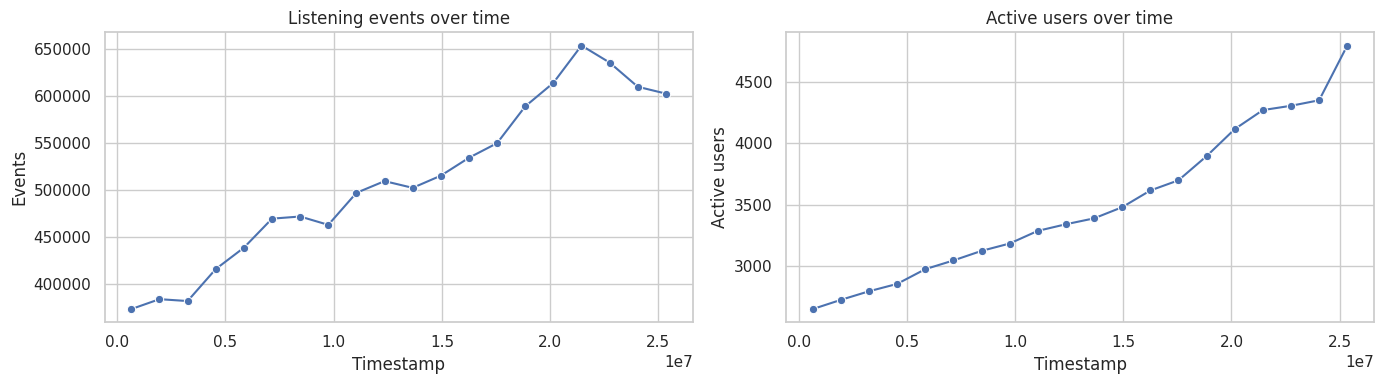

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(
    data=time_stats,
    x="timestamp_mid",
    y="events",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Listening events over time")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Events")

sns.lineplot(
    data=time_stats,
    x="timestamp_mid",
    y="active_users",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Active users over time")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Active users")

plt.tight_layout()
plt.show()

**Вывод:** Количество событий и активных пользователей растёт по мере увеличения timestamp. Это показывает, что активность в данных распределена неравномерно во времени.

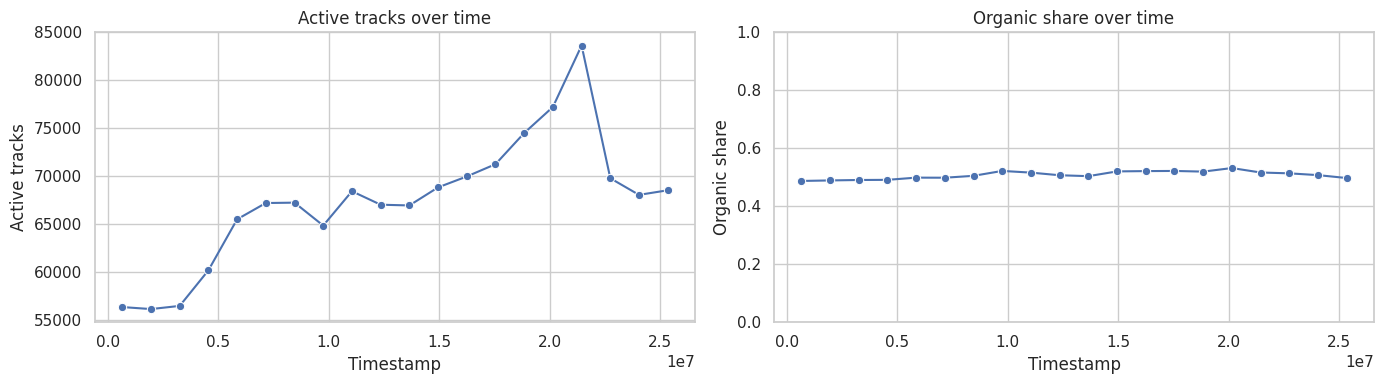

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(
    data=time_stats,
    x="timestamp_mid",
    y="active_tracks",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Active tracks over time")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Active tracks")

sns.lineplot(
    data=time_stats,
    x="timestamp_mid",
    y="organic_share",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Organic share over time")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Organic share")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Вывод:** Число активных треков меняется по времени, но доля organic interactions остаётся достаточно стабильной. Значит, в данных нет резкого временного сдвига по типу взаимодействий.

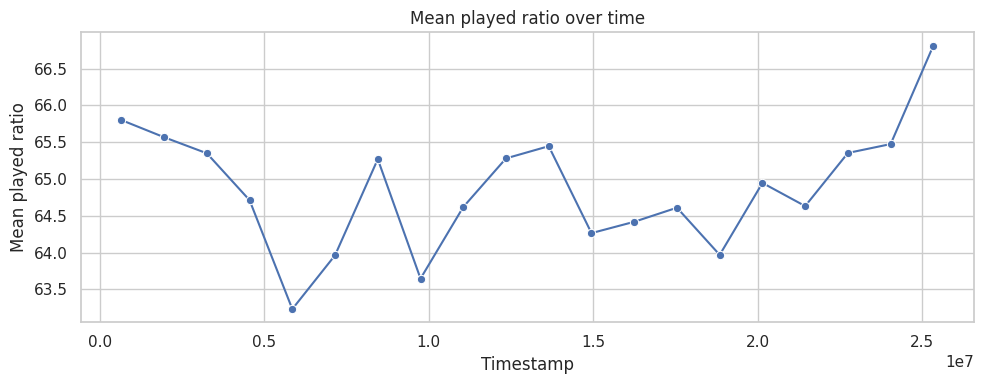

In [14]:
plt.figure(figsize=(10, 4))

sns.lineplot(
    data=time_stats,
    x="timestamp_mid",
    y="mean_played_ratio",
    marker="o"
)

plt.title("Mean played ratio over time")
plt.xlabel("Timestamp")
plt.ylabel("Mean played ratio")
plt.tight_layout()
plt.show()

**Вывод:** Средний played_ratio_pct колеблется по времени, но без сильного систематического сдвига. В целом качество прослушиваний остаётся сопоставимым на разных участках временной шкалы.

## 3. Leave-one-out split

Для оценки моделей используется схема leave-one-out. Для каждого пользователя последнее событие берётся как test target, предпоследнее - как validation target, а все более ранние события формируют train history. Такой split подходит для задачи next-item prediction, потому что модель оценивается на предсказании следующего трека по предыдущей истории пользователя.

In [15]:
def build_leave_one_out_split(events: pd.DataFrame, min_events: int = 3):
    df = events.sort_values(["uid", "timestamp"]).copy()
    lengths = df.groupby("uid")["item_id"].transform("size")
    df = df[lengths >= min_events].copy()

    df["pos"] = df.groupby("uid").cumcount()
    df["n_events"] = df.groupby("uid")["item_id"].transform("size")

    train = df[df["pos"] < df["n_events"] - 2].copy()
    val = df[df["pos"] == df["n_events"] - 2].copy()
    test = df[df["pos"] == df["n_events"] - 1].copy()

    return train, val, test

In [16]:
train_events, val_events, test_events = build_leave_one_out_split(final_events, min_events=3)

# оставляем только warm-start users/items
train_users = set(train_events["uid"].unique())
train_items = set(train_events["item_id"].unique())

val_events = val_events[val_events["uid"].isin(train_users) & val_events["item_id"].isin(train_items)].copy()
valid_val_users = set(val_events["uid"].unique())
test_events = test_events[test_events["uid"].isin(valid_val_users) & test_events["item_id"].isin(train_items)].copy()

In [17]:
# оставляем валидацию только для пользователей, которые остались в тесте
# синхронизирую validation и test по пользователям
# так каждая модель оценивается на одном и том же наборе пользователей
test_users = set(test_events["uid"].unique())
val_events = val_events[val_events["uid"].isin(test_users)].copy()
train_events_eval = train_events[train_events["uid"].isin(test_users)].copy()

In [18]:
split_summary = pd.DataFrame({
    "part": ["train_events", "validation_targets", "test_targets"],
    "rows": [len(train_events_eval), len(val_events), len(test_events)],
    "users": [
        train_events_eval["uid"].nunique(),
        val_events["uid"].nunique(),
        test_events["uid"].nunique()
    ],
    "items": [
        train_events_eval["item_id"].nunique(),
        val_events["item_id"].nunique(),
        test_events["item_id"].nunique()
    ]})

split_summary

,part,rows,users,items
0,train_events,10196170,4973,299841
1,validation_targets,4973,4973,3806
2,test_targets,4973,4973,3846


**Вывод:** После leave-one-out split в обучении остаётся около 10.2 млн событий, а validation и test содержат по 4973 target-события. Все target items оставлены только для warm-start пользователей и треков, то есть модели оцениваются на объектах, которые уже встречались в train.

Для baseline-моделей дополнительно формируются таблицы с контекстом: последним известным треком пользователя и целевым следующим треком. Для validation контекстом является последняя train-позиция, а для test - validation item.

In [19]:
last_train_item = (train_events_eval.sort_values(["uid", "timestamp"]).groupby("uid", as_index=False).tail(1)[["uid", "item_id"]].rename(columns={"item_id": "context_last_item"}))
val_eval = (val_events[["uid", "item_id"]].rename(columns={"item_id": "target"}).merge(last_train_item, on="uid", how="inner"))

test_context = val_events[["uid", "item_id"]].rename(columns={"item_id": "context_last_item"})
test_eval = (test_events[["uid", "item_id"]].rename(columns={"item_id": "target"}).merge(test_context, on="uid", how="inner"))

print("val_eval:", val_eval.shape)
print("test_eval:", test_eval.shape)

test_eval.head()

val_eval: (4973, 3)
test_eval: (4973, 3)


,uid,target,context_last_item
0,100,7415847,1299533
1,200,2859641,8729910
2,300,8033345,3349700
3,600,5148775,5995954
4,700,2439431,7801891


**Вывод:** Для каждого пользователя сформирована пара из контекстного трека и target item. Такой формат дальше используется в простых sequential baseline: Last Item и Item-to-Item. Для более сложных моделей, таких как GRU, будет использоваться уже вся доступная последовательность пользователя.

## 4. Метрики

Для сравнения моделей используются две группы метрик. Первая группа оценивает качество предсказания следующего трека: попала ли модель в правильный target и насколько высоко он оказался в списке рекомендаций. Вторая группа описывает сами рекомендации: насколько широко модель покрывает каталог и насколько сильно концентрируется на популярных треках.

Основной горизонт сравнения - @50. Метрики @10 также считаются в ноутбуке как дополнительная проверка, но в итоговых таблицах дальше основной акцент делается на @50.


In [20]:
def eval_next_item(eval_df: pd.DataFrame, recs: dict, ks=(10, 50)):
    rows = []

    users = eval_df["uid"].to_numpy()
    targets = eval_df["target"].to_numpy()
    n = len(eval_df)

    for k in ks:
        hits = 0
        mrr_sum = 0.0
        ndcg_sum = 0.0

        for u, target in zip(users, targets):
            pred = recs.get(u, [])
            pred_k = pred[:k]

            if target in pred_k:
                rank = pred_k.index(target) + 1
                hits += 1
                mrr_sum += 1.0 / rank
                ndcg_sum += 1.0 / np.log2(rank + 1)

        recall = hits / max(1, n)

        rows.append({
            "K": k,
            "Recall@K": recall,
            "Precision@K": recall / k,
            "NDCG@K": ndcg_sum / max(1, n),
            "MRR@K": mrr_sum / max(1, n),
        })

    return pd.DataFrame(rows)

Помимо качества попадания в target, важно оценить свойства самих рекомендательных списков. Для этого считаются метрики покрытия каталога и концентрации рекомендаций.


In [21]:
def gini_from_counts(counts):
    values = np.array(list(counts), dtype=float)

    if len(values) == 0:
        return np.nan

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)
    cum_values = np.cumsum(values)

    return (n + 1 - 2 * np.sum(cum_values) / cum_values[-1]) / n

In [22]:
def flatten_recommendations(recs: dict, k: int):
    flat = []

    for items in recs.values():
        flat.extend(items[:k])

    return flat

In [23]:
def recommendation_exposure_metrics(recs: dict, model_name: str, item_universe, popularity_bin_map: dict, ks=(10, 50)):
    rows = []
    catalog_size = len(set(item_universe))

    for k in ks:
        flat_recs = flatten_recommendations(recs, k=k)

        if len(flat_recs) == 0:
            rows.append({
                "model": model_name,
                "K": k,
                "Unique Recommended Items@K": 0,
                "Catalog Coverage@K": 0.0,
                "Gini@K": np.nan
            })
            continue

        rec_counts = pd.Series(flat_recs).value_counts()
        unique_recs = int(rec_counts.shape[0])

        rec_bins = pd.Series([popularity_bin_map.get(item, np.nan) for item in flat_recs])
        rec_bins = rec_bins.dropna()
        top_bin_share = float((rec_bins >= 8).mean()) if len(rec_bins) > 0 else np.nan

        rows.append({
            "model": model_name,
            "K": k,
            "Unique Recommended Items@K": unique_recs,
            "Catalog Coverage@K": unique_recs / max(1, catalog_size),
            "Gini@K": gini_from_counts(rec_counts.values)
        })

    return pd.DataFrame(rows)


popularity_bin_map = dict(zip(item_pop_df["item_id"], item_pop_df["popularity_bin"]))
item_universe = train_events_eval["item_id"].unique()

## 5. Baseline 1: Most Popular

In [24]:
def build_most_popular(train_events: pd.DataFrame, top_n: int = 500):
    return train_events["item_id"].value_counts().head(top_n).index.tolist()

In [25]:
popular_list = build_most_popular(train_events_eval, top_n=500)
recs_pop = {uid: popular_list for uid in test_eval["uid"].unique()}

results_pop = eval_next_item(test_eval, recs_pop, ks=(10, 50))
results_pop.insert(0, "model", "Most Popular")
results_pop

,model,K,Recall@K,Precision@K,NDCG@K,MRR@K
0,Most Popular,10,0.015886,0.001589,0.006476,0.003708
1,Most Popular,50,0.055701,0.001114,0.014858,0.005311


## 6. Baseline 2: Last Item

In [26]:
def recommend_last_item(eval_df: pd.DataFrame, fallback_popular: list, k: int = 500):
    recs = {}

    for row in eval_df.itertuples(index=False):
        rec = [row.context_last_item]

        for item in fallback_popular:
            if item not in rec:
                rec.append(item)
            if len(rec) >= k:
                break

        recs[row.uid] = rec

    return recs

In [27]:
recs_last = recommend_last_item(test_eval, popular_list, k=500)

results_last = eval_next_item(test_eval, recs_last, ks=(10, 50))
results_last.insert(0, "model", "Last Item")
results_last

,model,K,Recall@K,Precision@K,NDCG@K,MRR@K
0,Last Item,10,0.066358,0.006636,0.058113,0.055711
1,Last Item,50,0.105771,0.002115,0.066454,0.057334


## 7. Baseline 3: Item-to-Item / first-order Markov

In [28]:
def build_transition_model(train_events: pd.DataFrame, min_count: int = 2, top_m_per_item: int = 500):
    df = train_events.sort_values(["uid", "timestamp"])[["uid", "item_id"]].copy()
    df["prev_item"] = df.groupby("uid")["item_id"].shift(1)
    df = df.dropna(subset=["prev_item"]).copy()

    trans = (df.groupby(["prev_item", "item_id"]).size().reset_index(name="cnt"))

    trans = trans[trans["cnt"] >= min_count]
    trans = trans.sort_values(["prev_item", "cnt"], ascending=[True, False])
    trans = trans.groupby("prev_item").head(top_m_per_item)

    return trans.groupby("prev_item")["item_id"].apply(list).to_dict()

In [29]:
def recommend_item_to_item(eval_df: pd.DataFrame, transition_model: dict, fallback_popular: list, k: int = 500):
    recs = {}

    for row in eval_df.itertuples(index=False):
        rec = []

        if row.context_last_item in transition_model:
            rec.extend(transition_model[row.context_last_item])

        for item in fallback_popular:
            if item not in rec:
                rec.append(item)
            if len(rec) >= k:
                break

        recs[row.uid] = rec[:k]

    return recs

In [30]:
transition_model = build_transition_model(train_events_eval, min_count=2, top_m_per_item=500)

print("Items with transition history:", len(transition_model))

recs_i2i = recommend_item_to_item(test_eval, transition_model, popular_list, k=500)
results_i2i = eval_next_item(test_eval, recs_i2i, ks=(10, 50))
results_i2i.insert(0, "model", "Item-to-Item")
results_i2i

Items with transition history: 84386


,model,K,Recall@K,Precision@K,NDCG@K,MRR@K
0,Item-to-Item,10,0.167706,0.016771,0.116417,0.100398
1,Item-to-Item,50,0.241102,0.004822,0.132585,0.103845


## 8. Сводная таблица baseline-моделей

In [31]:
baseline_results = pd.concat([results_pop, results_last, results_i2i], ignore_index=True)
baseline_results

,model,K,Recall@K,Precision@K,NDCG@K,MRR@K
0,Most Popular,10,0.015886,0.001589,0.006476,0.003708
1,Most Popular,50,0.055701,0.001114,0.014858,0.005311
2,Last Item,10,0.066358,0.006636,0.058113,0.055711
3,Last Item,50,0.105771,0.002115,0.066454,0.057334
4,Item-to-Item,10,0.167706,0.016771,0.116417,0.100398
5,Item-to-Item,50,0.241102,0.004822,0.132585,0.103845


**Вывод:** Среди простых baseline-моделей лучший результат показывает Item-to-Item: он заметно превосходит Most Popular и Last Item по всем ranking-метрикам. Это ожидаемо для задачи next-track prediction, потому что модель учитывает локальные переходы между треками. Most Popular оказывается самым слабым вариантом, так как не использует индивидуальную историю пользователя. Last Item занимает промежуточное положение и показывает, что последний прослушанный трек сам по себе уже несёт полезный сигнал.

## 9. Подготовка данных для GRU

После простых baseline-моделей я перехожу к нейросетевой последовательной модели GRU. В отличие от Most Popular, Last Item и Item-to-Item, GRU использует не только последний трек или локальный переход, а всю доступную последовательность пользователя в ограниченном окне.

Для этого треки переводятся в числовые индексы, а пользовательские истории приводятся к фиксированной длине MAX_LEN. Если история короче, она дополняется padding-значениями, если длиннее, то берутся последние события.

In [32]:
# параметры для подготовки последовательностей перед первым запуском gru
MAX_LEN = 50
MAX_TRAIN_SAMPLES_PER_USER = 10

# строю внутреннюю индексацию треков только по train
item_ids = train_events_eval["item_id"].drop_duplicates().tolist()
item2idx = {item_id: idx + 1 for idx, item_id in enumerate(item_ids)}
idx2item = {idx: item_id for item_id, idx in item2idx.items()}
num_items = len(item2idx) + 1

print("num_items:", num_items)

num_items: 299842


In [33]:
def pad_sequence(seq, max_len, pad_value=0):
    seq = seq[-max_len:]
    return [pad_value] * (max_len - len(seq)) + seq


train_encoded = train_events_eval.sort_values(["uid", "timestamp"]).copy()
train_encoded["item_idx"] = train_encoded["item_id"].map(item2idx)

val_encoded = val_events[val_events["uid"].isin(test_users)].copy()
val_encoded = val_encoded[val_encoded["item_id"].isin(item2idx)].copy()
val_encoded["target_idx"] = val_encoded["item_id"].map(item2idx).astype(int)

test_encoded = test_events[test_events["uid"].isin(test_users)].copy()
test_encoded = test_encoded[test_encoded["item_id"].isin(item2idx)].copy()
test_encoded["target_idx"] = test_encoded["item_id"].map(item2idx).astype(int)

user_train_seq = train_encoded.groupby("uid")["item_idx"].apply(list).to_dict()
user_val_target = dict(zip(val_encoded["uid"], val_encoded["target_idx"]))
user_test_target = dict(zip(test_encoded["uid"], test_encoded["target_idx"]))
user_val_item_idx = user_val_target.copy()

train_samples = []
val_samples = []
test_samples = []

for uid, seq in user_train_seq.items():
    if len(seq) >= 2:
        start_i = max(1, len(seq) - MAX_TRAIN_SAMPLES_PER_USER)

        for i in range(start_i, len(seq)):
            train_samples.append({
                "uid": uid,
                "input_seq": pad_sequence(seq[:i], MAX_LEN),
                "target": seq[i]
            })

    if uid in user_val_target and len(seq) >= 1:
        val_samples.append({
            "uid": uid,
            "input_seq": pad_sequence(seq, MAX_LEN),
            "target": user_val_target[uid]
        })

    if uid in user_test_target and uid in user_val_item_idx and len(seq) >= 1:
        test_input = seq + [user_val_item_idx[uid]]
        test_samples.append({
            "uid": uid,
            "input_seq": pad_sequence(test_input, MAX_LEN),
            "target": user_test_target[uid]
        })

train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (49329, 3)
val_df: (4973, 3)
test_df: (4973, 3)


## 10. GRU baseline

GRU используется как простой нейросетевой sequential baseline. Эта модель обрабатывает историю прослушиваний по порядку и формирует скрытое состояние, которое затем используется для предсказания следующего трека. Вообще, в  данном ноутбуке GRU нужна не как финальная модель, а как промежуточный benchmark между простыми baseline-моделями и более сложной self-attention моделью SASRec.

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

MAX_LEN = 100
MAX_TRAIN_SAMPLES_PER_USER = 50
NUM_EPOCHS = 13
EMB_DIM = 128
HIDDEN_DIM = 128
BATCH_SIZE = 8
LR = 1e-3

print("device:", device)

device: cuda


In [35]:
class SeqRecDataset(Dataset):
    def __init__(self, df):
        self.inputs = df["input_seq"].tolist()
        self.targets = df["target"].tolist()

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx], dtype=torch.long),
            torch.tensor(self.targets[idx], dtype=torch.long)
        )

In [36]:
train_loader = DataLoader(SeqRecDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SeqRecDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SeqRecDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 6167
val batches: 622
test batches: 622


In [37]:
class GRURec(nn.Module):
    def __init__(self, num_items, emb_dim=64, hidden_dim=64, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(num_items, emb_dim, padding_idx=padding_idx)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, num_items)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.gru(emb)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


@torch.no_grad()
def evaluate_torch(model, loader, ks=(10, 50)):
    model.eval()

    total = 0
    hits = {k: 0.0 for k in ks}
    mrrs = {k: 0.0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        logits = model(x)

        total += y.size(0)

        for k in ks:
            topk = torch.topk(logits, k=k, dim=1).indices

            for i in range(y.size(0)):
                preds = topk[i].tolist()
                target = y[i].item()

                if target in preds:
                    rank = preds.index(target) + 1
                    hits[k] += 1
                    mrrs[k] += 1.0 / rank
                    ndcgs[k] += 1.0 / np.log2(rank + 1)

    out = {}
    for k in ks:
        recall = hits[k] / max(1, total)
        out[f"Recall@{k}"] = recall
        out[f"Precision@{k}"] = recall / k
        out[f"NDCG@{k}"] = ndcgs[k] / max(1, total)
        out[f"MRR@{k}"] = mrrs[k] / max(1, total)

    return out


@torch.no_grad()
def generate_gru_recommendations(model, loader, eval_df, idx2item, top_k=50):
    model.eval()

    recs = {}
    eval_users = eval_df["uid"].tolist()
    pointer = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        logits = model(x)
        topk = torch.topk(logits, k=top_k, dim=1).indices.cpu().numpy()

        for pred_idxs in topk:
            uid = eval_users[pointer]
            recs[uid] = [
                idx2item[int(idx)]
                for idx in pred_idxs
                if int(idx) in idx2item
            ]
            pointer += 1

    return recs


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum = 0.0
    start = time.time()

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

    return loss_sum / max(1, len(loader)), time.time() - start

In [38]:
# обучаю gru и сохраняю историю validation-метрик
gru_model = GRURec(num_items=num_items, emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LR)

gru_history = []

for epoch in range(NUM_EPOCHS):
    train_loss, epoch_time = train_one_epoch(gru_model, train_loader, optimizer, criterion)
    val_metrics = evaluate_torch(gru_model, val_loader, ks=(10, 50))

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "epoch_time_sec": epoch_time,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }
    gru_history.append(row)

    print(f"epoch {epoch + 1}")
    print(f"train loss: {train_loss:.4f}")
    print(f"time sec: {epoch_time:.2f}")
    print("val:", val_metrics)

# test считаю один раз после обучения модели
gru_test_metrics = evaluate_torch(gru_model, test_loader, ks=(10, 50))
print("test:", gru_test_metrics)

# отдельные top-50 списки нужны для coverage и gini
recs_gru = generate_gru_recommendations(
    model=gru_model,
    loader=test_loader,
    eval_df=test_eval,
    idx2item=idx2item,
    top_k=50
)

gru_result_long = pd.DataFrame([
    {
        "model": "GRU",
        "K": k,
        "Recall@K": gru_test_metrics[f"Recall@{k}"],
        "Precision@K": gru_test_metrics[f"Precision@{k}"],
        "NDCG@K": gru_test_metrics[f"NDCG@{k}"],
        "MRR@K": gru_test_metrics[f"MRR@{k}"],
    }
    for k in (10, 50)
])

pd.DataFrame(gru_history)

  0%|          | 0/6167 [00:00<?, ?it/s]

  0%|          | 0/622 [00:00<?, ?it/s]

epoch 1
train loss: 11.0539
time sec: 36.32
val: {'Recall@10': 0.04041825859642067, 'Precision@10': 0.0040418258596420665, 'NDCG@10': np.float64(0.026485529192817714), 'MRR@10': 0.022225653449260935, 'Recall@50': 0.0776191433742208, 'Precision@50': 0.0015523828674844158, 'NDCG@50': np.float64(0.03443634738820572), 'MRR@50': 0.023806728537416676}


  0%|          | 0/6167 [00:00<?, ?it/s]

  0%|          | 0/622 [00:00<?, ?it/s]

...

epoch 13
train loss: 2.2953
time sec: 35.69
val: {'Recall@10': 0.10898853810577117, 'Precision@10': 0.010898853810577116, 'NDCG@10': np.float64(0.0793029237883787), 'MRR@10': 0.06998418443723085, 'Recall@50': 0.15483611502111402, 'Precision@50': 0.0030967223004222805, 'NDCG@50': np.float64(0.08932554029405401), 'MRR@50': 0.07208033664730386}


  0%|          | 0/622 [00:00<?, ?it/s]

test: {'Recall@10': 0.09712447214960788, 'Precision@10': 0.009712447214960788, 'NDCG@10': np.float64(0.06869786805026482), 'MRR@10': 0.0598436318022081, 'Recall@50': 0.13553187210939072, 'Precision@50': 0.0027106374421878143, 'NDCG@50': np.float64(0.07717812690560569), 'MRR@50': 0.06166316139742107}


  0%|          | 0/622 [00:00<?, ?it/s]

,epoch,train_loss,epoch_time_sec,val_Recall@10,val_Precision@10,val_NDCG@10,val_MRR@10,val_Recall@50,val_Precision@50,val_NDCG@50,val_MRR@50
0,1,11.053931,36.319308,0.040418,0.004042,0.026486,0.022226,0.077619,0.001552,0.034436,0.023807
1,2,8.902739,35.614374,0.066157,0.006616,0.046766,0.040769,0.109391,0.002188,0.056331,0.042827
2,3,7.665154,35.496547,0.081239,0.008124,0.059680,0.052891,0.126684,0.002534,0.069442,0.054854
3,4,6.541359,35.529239,0.091293,0.009129,0.066425,0.058612,0.136336,0.002727,0.076326,0.060711
4,5,5.592216,35.492389,0.093505,0.009350,0.068412,0.060491,0.143776,0.002876,0.079435,0.062812
5,6,4.816411,35.614063,0.099336,0.009934,0.071542,0.062872,0.146793,0.002936,0.081928,0.065052
6,7,4.177706,35.676605,0.101146,0.010115,0.074223,0.065760,0.148401,0.002968,0.084462,0.067858
7,8,3.675335,35.583407,0.104967,0.010497,0.077752,0.069243,0.150211,0.003004,0.087544,0.071247
8,9,3.255229,35.540487,0.106777,0.010678,0.079150,0.070524,0.154434,0.003089,0.089534,0.072687
9,10,2.939941,35.573991,0.106374,0.010637,0.077289,0.068145,0.152624,0.003052,0.087432,0.070281


**Вывод:** По мере обучения train loss снижается, а validation-метрики растут, значит модель действительно извлекает сигнал из пользовательских последовательностей. При этом качество GRU остаётся ниже сильного Item-to-Item baseline, что показывает: простая recurrent-модель не полностью улавливает структуру переходов между треками.

## 11. Итоговое сравнение моделей по расширенному набору метрик

В этом блоке baseline-модели и GRU сравниваются по единому набору метрик:

- Recall@K
- Precision@K
- NDCG@K
- MRR@K
- Catalog Coverage@K
- Gini@K

Основная итоговая таблица строится на @50, но @10 также сохраняется в таблицах в длинном формате.

In [39]:
# объединяю ranking-метрики простых baseline-моделей и gru
baseline_accuracy_results = baseline_results.copy()
accuracy_results_long = pd.concat([baseline_accuracy_results, gru_result_long], ignore_index=True)
accuracy_results_long

,model,K,Recall@K,Precision@K,NDCG@K,MRR@K
0,Most Popular,10,0.015886,0.001589,0.006476,0.003708
1,Most Popular,50,0.055701,0.001114,0.014858,0.005311
2,Last Item,10,0.066358,0.006636,0.058113,0.055711
3,Last Item,50,0.105771,0.002115,0.066454,0.057334
4,Item-to-Item,10,0.167706,0.016771,0.116417,0.100398
5,Item-to-Item,50,0.241102,0.004822,0.132585,0.103845
6,GRU,10,0.097124,0.009712,0.068698,0.059844
7,GRU,50,0.135532,0.002711,0.077178,0.061663


**Вывод:** По ranking-метрикам лучшей моделью остаётся Item-to-Item: она показывает максимальные Recall@50, NDCG@50 и MRR@50 среди моделей этого ноутбука. Это означает, что локальные переходы между треками хорошо описывают задачу предсказания следующего трека. GRU улучшает Most Popular и Last Item по Recall@50, но уступает Item-to-Item, вероятно, потому что простая GRU-модель хуже улавливает частые парные переходы между треками.

In [40]:
# считаю свойства рекомендательных списков для всех моделей из этого ноутбука
recommendation_property_results = pd.concat(
    [
        recommendation_exposure_metrics(
            recs_pop,
            model_name="Most Popular",
            item_universe=item_universe,
            popularity_bin_map=popularity_bin_map,
            ks=(10, 50)
        ),
        recommendation_exposure_metrics(
            recs_last,
            model_name="Last Item",
            item_universe=item_universe,
            popularity_bin_map=popularity_bin_map,
            ks=(10, 50)
        ),
        recommendation_exposure_metrics(
            recs_i2i,
            model_name="Item-to-Item",
            item_universe=item_universe,
            popularity_bin_map=popularity_bin_map,
            ks=(10, 50)
        ),
        recommendation_exposure_metrics(
            recs_gru,
            model_name="GRU",
            item_universe=item_universe,
            popularity_bin_map=popularity_bin_map,
            ks=(10, 50)
        ),
    ],
    ignore_index=True)

recommendation_property_results

,model,K,Unique Recommended Items@K,Catalog Coverage@K,Gini@K
0,Most Popular,10,10,0.000033,0.000000
1,Most Popular,50,50,0.000167,0.000000
2,Last Item,10,3806,0.012693,0.918574
3,Last Item,50,3807,0.012697,0.971492
4,Item-to-Item,10,12702,0.042362,0.648057
5,Item-to-Item,50,21406,0.071391,0.827717
6,GRU,10,4534,0.015121,0.700939
7,GRU,50,7372,0.024586,0.743935


**Вывод:** На этом этапе самым сильным baseline является Item-to-Item: он лучше остальных простых моделей и GRU по качеству ранжирования и одновременно даёт наибольшее покрытие каталога. GRU показывает, что нейросетевая последовательная модель извлекает полезный сигнал из истории пользователя, но в текущей простой конфигурации не превосходит Item-to-Item. Поэтому дальше Item-to-Item используется как сильный baseline, а развитие нейросетевого подхода продолжается через SASRec.

In [41]:
# объединяю accuracy-метрики и метрики свойств рекомендаций
final_model_metrics_long = accuracy_results_long.merge(recommendation_property_results, on=["model", "K"], how="left")
final_model_metrics_long

,model,K,Recall@K,Precision@K,NDCG@K,MRR@K,Unique Recommended Items@K,Catalog Coverage@K,Gini@K
0,Most Popular,10,0.015886,0.001589,0.006476,0.003708,10,0.000033,0.000000
1,Most Popular,50,0.055701,0.001114,0.014858,0.005311,50,0.000167,0.000000
2,Last Item,10,0.066358,0.006636,0.058113,0.055711,3806,0.012693,0.918574
3,Last Item,50,0.105771,0.002115,0.066454,0.057334,3807,0.012697,0.971492
4,Item-to-Item,10,0.167706,0.016771,0.116417,0.100398,12702,0.042362,0.648057
5,Item-to-Item,50,0.241102,0.004822,0.132585,0.103845,21406,0.071391,0.827717
6,GRU,10,0.097124,0.009712,0.068698,0.059844,4534,0.015121,0.700939
7,GRU,50,0.135532,0.002711,0.077178,0.061663,7372,0.024586,0.743935


In [42]:
final_model_metrics_at50 = (final_model_metrics_long.query("K == 50").copy()
    .rename(columns={
        "Recall@K": "Recall@50",
        "Precision@K": "Precision@50",
        "NDCG@K": "NDCG@50",
        "MRR@K": "MRR@50",
        "Catalog Coverage@K": "Catalog Coverage@50",
        "Unique Recommended Items@K": "Unique Recommended Items@50",
        "Gini@K": "Gini@50"

    }))

final_model_metrics_at50 = final_model_metrics_at50[
    [
        "model",
        "Recall@50",
        "Precision@50",
        "NDCG@50",
        "MRR@50",
        "Catalog Coverage@50",
        "Unique Recommended Items@50",
        "Gini@50"]]

final_model_metrics_at50

,model,Recall@50,Precision@50,NDCG@50,MRR@50,Catalog Coverage@50,Unique Recommended Items@50,Gini@50
1,Most Popular,0.055701,0.001114,0.014858,0.005311,0.000167,50,0.000000
3,Last Item,0.105771,0.002115,0.066454,0.057334,0.012697,3807,0.971492
5,Item-to-Item,0.241102,0.004822,0.132585,0.103845,0.071391,21406,0.827717
7,GRU,0.135532,0.002711,0.077178,0.061663,0.024586,7372,0.743935
